# Catastrophic Forgetting Across Neural Network Architectures

This Jupyter notebook systematically evaluates **Backpropagation** vs **Predictive Coding (`jpc`)** in a sequential class-learning experiment on MNIST across four specific architectures:

1. **`784 - 100 - 10`** (1 hidden layer, 100 neurons)
2. **`784 - 500 - 10`** (1 hidden layer, 500 neurons)
3. **`784 - 1000 - 10`** (1 hidden layer, 1000 neurons)
4. **`784 - 300 - 300 - 10`** (2 hidden layers, 300 neurons each)

## Setup & Data Loading

In [3]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from typing import Any, Dict

root_dir = Path.cwd().resolve()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.data import download_mnist
from src.experiments.forgetting import (
    build_forgetting_loaders,
    run_forgetting_experiment
)

print("Loading MNIST dataset (keep_prop=0.5)...")
train_set, valid_set, test_set = download_mnist()
loaders = build_forgetting_loaders(train_set, valid_set, batch_size=64)
num_epochs = 5
results_history = {}
print("Setup completed successfully!")

Loading MNIST dataset (keep_prop=0.5)...
Number of examples retained:
  48001 (training)
  11999 (validation)
  10000 (test)
Setup completed successfully!

In [4]:
def run_and_plot_architecture(arch_label, num_hidden, num_hidden_layers=1):
    print(f"--- Running Experiments for Architecture: {arch_label} ---")
    
    # Run Backprop
    bp_res = run_forgetting_experiment(
        train_loader_old=loaders["train_loader_old"],
        valid_loader_old=loaders["valid_loader_old"],
        train_loader_new=loaders["train_loader_new"],
        valid_loader_new=loaders["valid_loader_new"],
        train_loader_full=loaders["train_loader_full"],
        model_type="backprop",
        num_epochs_phase1=num_epochs,
        num_epochs_phase2=num_epochs,
        num_hidden=num_hidden,
        num_hidden_layers=num_hidden_layers,
        lr=0.1,
        verbose=False,
    )
    
    # Run Predictive Coding
    pc_res = run_forgetting_experiment(
        train_loader_old=loaders["train_loader_old"],
        valid_loader_old=loaders["valid_loader_old"],
        train_loader_new=loaders["train_loader_new"],
        valid_loader_new=loaders["valid_loader_new"],
        train_loader_full=loaders["train_loader_full"],
        model_type="predictive_coding",
        num_epochs_phase1=num_epochs,
        num_epochs_phase2=num_epochs,
        num_hidden=num_hidden,
        num_hidden_layers=num_hidden_layers,
        lr=1e-3,
        verbose=False,
    )
    
    bp_trace = bp_res["old_class_acc_trace"]
    pc_trace = pc_res["old_class_acc_trace"]
    
    bp_p1 = float(bp_trace[num_epochs - 1])
    bp_p2 = float(bp_trace[-1])
    bp_new = float(bp_res["new_class_acc_final"])
    
    pc_p1 = float(pc_trace[num_epochs - 1])
    pc_p2 = float(pc_trace[-1])
    pc_new = float(pc_res["new_class_acc_final"])
    
    print(f"Backprop           -> Phase 1 Acc: {bp_p1:.1f}%, Retained Acc: {bp_p2:.1f}%, New Task Acc: {bp_new:.1f}%")
    print(f"Predictive Coding  -> Phase 1 Acc: {pc_p1:.1f}%, Retained Acc: {pc_p2:.1f}%, New Task Acc: {pc_new:.1f}%")
    
    # Plot curves
    fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
    epochs_axis = list(range(1, len(bp_trace) + 1))
    ax.axvspan(0.5, num_epochs + 0.5, color="#e6f2ff", alpha=0.5, label="Phase 1 (Digits 0-5)")
    ax.axvspan(num_epochs + 0.5, len(bp_trace) + 0.5, color="#fff0e6", alpha=0.5, label="Phase 2 (Digits 6-9)")
    
    ax.plot(epochs_axis, bp_trace, "o-", label=f"Backprop ({arch_label})", color="#1f77b4", linewidth=2.2)
    ax.plot(epochs_axis, pc_trace, "s-", label=f"Predictive Coding ({arch_label})", color="#d62728", linewidth=2.2)
    ax.axvline(num_epochs + 0.5, color="#7f7f7f", linestyle="--", linewidth=1.2)
    
    ax.set_title(f"Forgetting Curve: {arch_label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Training Epoch", fontsize=10)
    ax.set_ylabel("Accuracy on Digits 0-5 (%)", fontsize=10)
    ax.set_xlim(0.5, len(bp_trace) + 0.5)
    ax.set_ylim(-2, 102)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="lower left", frameon=True, facecolor="white", framealpha=0.95)
    plt.tight_layout()
    plt.show()
    
    res = {
        "bp": {"p1_acc": bp_p1, "retained_acc": bp_p2, "new_acc": bp_new, "trace": bp_trace},
        "pc": {"p1_acc": pc_p1, "retained_acc": pc_p2, "new_acc": pc_new, "trace": pc_trace},
    }
    results_history[arch_label] = res
    return res


def save_experiment_results(results: Dict[str, Any], filepath: str) -> None:
    """Save experiment summary metrics to a JSON file."""
    import json
    from pathlib import Path

    path = Path(filepath)
    path.parent.mkdir(parents=True, exist_ok=True)

    serializable = {}
    for key, val in results.items():
        if isinstance(val, dict):
            item = {}
            for k, v in val.items():
                if k == "model":
                    continue
                if isinstance(v, (np.ndarray, torch.Tensor)):
                    item[k] = v.tolist()
                elif isinstance(v, (np.floating, np.integer)):
                    item[k] = float(v)
                else:
                    item[k] = v
            serializable[key] = item
        else:
            serializable[key] = val

    with open(path, "w", encoding="utf-8") as f:
        json.dump(serializable, f, indent=2)

## Section 1: Architecture `784 - 100 - 10`
*Single hidden layer with 100 neurons.*

--- Running Experiments for Architecture: 784-100-10 ---
Backprop           -> Phase 1 Acc: 96.1%, Retained Acc: 0.8%, New Task Acc: 97.4%
Predictive Coding  -> Phase 1 Acc: 98.2%, Retained Acc: 0.1%, New Task Acc: 98.3%

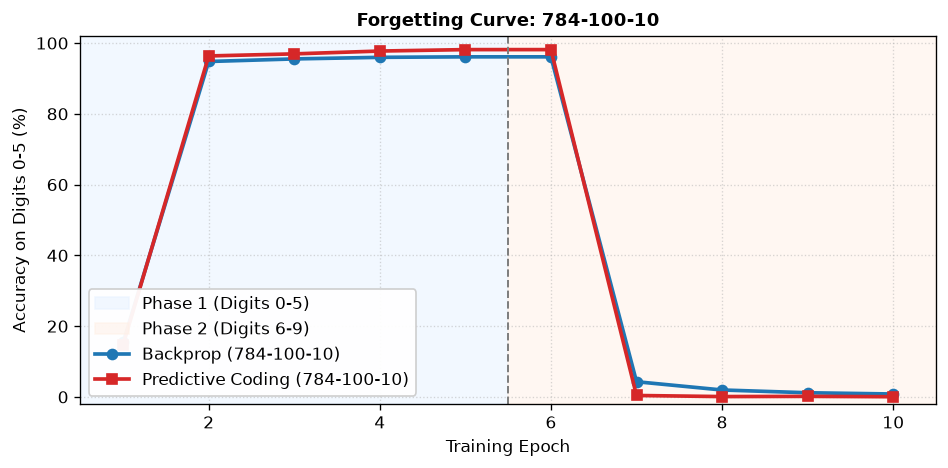

In [6]:
res_100 = run_and_plot_architecture("784-100-10", num_hidden=100, num_hidden_layers=1)

## Section 2: Architecture `784 - 500 - 10`
*Single hidden layer with 500 neurons.*

--- Running Experiments for Architecture: 784-500-10 ---
Backprop           -> Phase 1 Acc: 95.8%, Retained Acc: 1.0%, New Task Acc: 96.8%
Predictive Coding  -> Phase 1 Acc: 98.6%, Retained Acc: 0.0%, New Task Acc: 98.7%

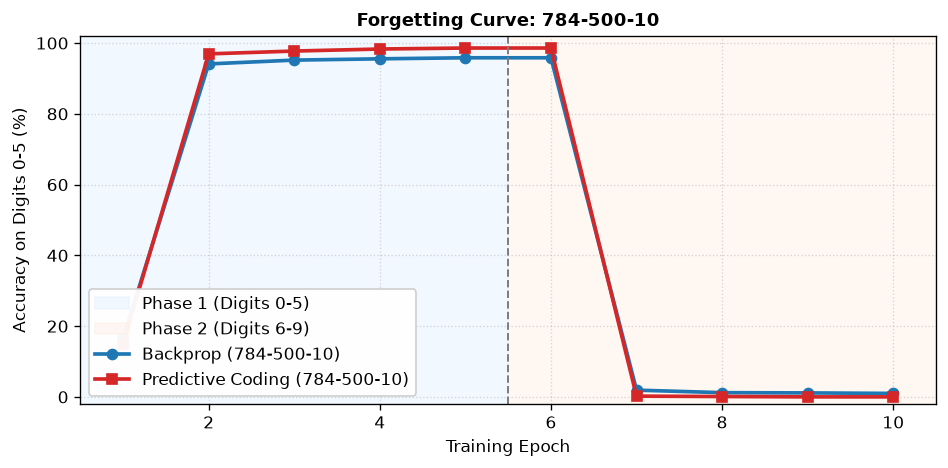

In [8]:
res_500 = run_and_plot_architecture("784-500-10", num_hidden=500, num_hidden_layers=1)

## Section 3: Architecture `784 - 1000 - 10`
*Single hidden layer with 1000 neurons.*

--- Running Experiments for Architecture: 784-1000-10 ---
Backprop           -> Phase 1 Acc: 95.9%, Retained Acc: 1.8%, New Task Acc: 96.7%
Predictive Coding  -> Phase 1 Acc: 98.5%, Retained Acc: 0.1%, New Task Acc: 98.6%

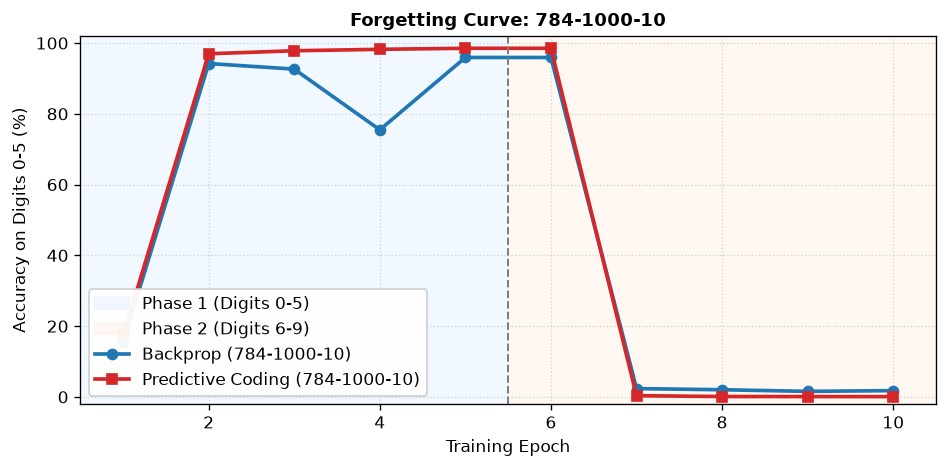

In [10]:
res_1000 = run_and_plot_architecture("784-1000-10", num_hidden=1000, num_hidden_layers=1)

## Section 4: Architecture `784 - 300 - 300 - 10`
*Two hidden layers with 300 neurons each.*

--- Running Experiments for Architecture: 784-300-300-10 ---
Backprop           -> Phase 1 Acc: 94.5%, Retained Acc: 0.0%, New Task Acc: 96.4%
Predictive Coding  -> Phase 1 Acc: 98.0%, Retained Acc: 0.0%, New Task Acc: 98.5%

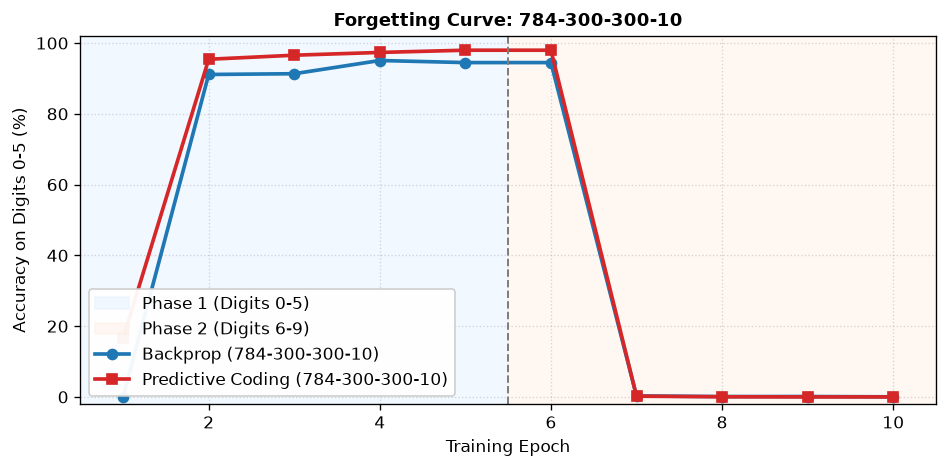

In [12]:
res_300_300 = run_and_plot_architecture("784-300-300-10", num_hidden=[300, 300], num_hidden_layers=2)

## Section 5: Deep Architecture `784 - 200 - 200 - 200 - 200 - 200 - 10`
*Five hidden layers deep (200 neurons per layer).*

--- Running Experiments for Architecture: 784-200-200-200-200-200-10 ---
Backprop           -> Phase 1 Acc: 16.5%, Retained Acc: 0.0%, New Task Acc: 24.5%
Predictive Coding  -> Phase 1 Acc: 33.5%, Retained Acc: 0.0%, New Task Acc: 94.2%

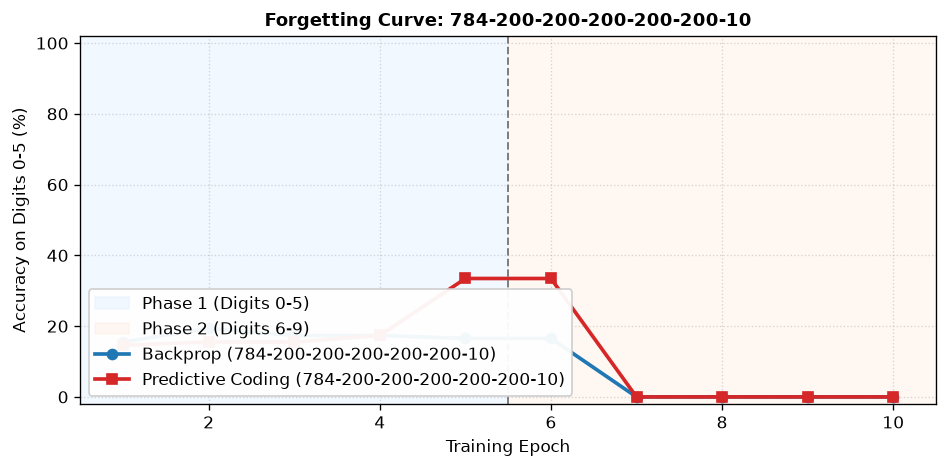

In [14]:
res_5layers = run_and_plot_architecture("784-200-200-200-200-200-10", num_hidden=[200]*5, num_hidden_layers=5)

## Section 6: Architecture Comparison & Summary Table

In [16]:
from IPython.display import display, Markdown

md_table = """
### Performance Summary Across Architectures

| Model | Architecture | Phase 1 Acc (Digits 0–5) | Retained Acc (Digits 0–5) | New Task Acc (Digits 6–9) |
| :--- | :---: | :---: | :---: | :---: |
"""

for arch, data in results_history.items():
    bp = data["bp"]
    pc = data["pc"]
    md_table += f"| **Backprop** | `{arch}` | **{bp['p1_acc']:.1f}%** | **{bp['retained_acc']:.1f}%** | **{bp['new_acc']:.1f}%** |\n"
    md_table += f"| **Predictive Coding** | `{arch}` | **{pc['p1_acc']:.1f}%** | **{pc['retained_acc']:.1f}%** | **{pc['new_acc']:.1f}%** |\n"

display(Markdown(md_table))

# Save output to data/results/notebook_architecture_results.json
out_file = root_dir / "data" / "results" / "notebook_architecture_results.json"
save_experiment_results(results_history, str(out_file))
print(f"Results successfully saved to {out_file}")


### Performance Summary Across Architectures

| Model | Architecture | Phase 1 Acc (Digits 0–5) | Retained Acc (Digits 0–5) | New Task Acc (Digits 6–9) |
| :--- | :---: | :---: | :---: | :---: |
| **Backprop** | `784-100-10` | **96.1%** | **0.8%** | **97.4%** |
| **Predictive Coding** | `784-100-10` | **98.2%** | **0.1%** | **98.3%** |
| **Backprop** | `784-500-10` | **95.8%** | **1.0%** | **96.8%** |
| **Predictive Coding** | `784-500-10` | **98.6%** | **0.0%** | **98.7%** |
| **Backprop** | `784-1000-10` | **95.9%** | **1.8%** | **96.7%** |
| **Predictive Coding** | `784-1000-10` | **98.5%** | **0.1%** | **98.6%** |
| **Backprop** | `784-300-300-10` | **94.5%** | **0.0%** | **96.4%** |
| **Predictive Coding** | `784-300-300-10` | **98.0%** | **0.0%** | **98.5%** |
| **Backprop** | `784-200-200-200-200-200-10` | **16.5%** | **0.0%** | **24.5%** |
| **Predictive Coding** | `784-200-200-200-200-200-10` | **33.5%** | **0.0%** | **94.2%** |

Results successfully saved to /home/aadam/workspace/Catastrophically-Forgotten/data/results/notebook_architecture_results.json